In [1]:
from astropy.table import Table, vstack
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import scienceplots
import fitsio
import healpy as hp
from multiprocessing import Pool
from functools import partial
import glob
plt.style.use(['science', 'notebook', 'grid'])
from flux_to_mag_desi import flux_mag
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import List, Optional
import os
import hashlib

/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
input_dir1 = "/storage/shadab/data/legacy_survey/dr9/north/sweep/9.0/"
tot_files = glob.glob(input_dir1+"*.fits")
files = np.random.choice(tot_files,40,replace=False)

In [3]:
colnames = ['RA', 'DEC', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z','FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z']

In [5]:
def read_data(file, n_sample=100000):
    with fitsio.FITS(file) as f:
        nrows = f[1].get_nrows()
        if nrows <= n_sample:
            # If file has fewer rows than sample size, read all
            return f[1].read()
        else:
            # Read random subset without replacement
            idx = np.random.choice(nrows, n_sample, replace=False)
            idx.sort()  # Sorting indices improves disk read performance
            return f[1].read(rows=idx)
        
def read_data_fast(file, n_sample=100000,col=None):
    with fitsio.FITS(file) as f:
        nrows = f[1].get_nrows()
        nsamples = min(n_sample, nrows)
        chunk_size = min(5*nsamples,nrows)
        start = np.random.randint(0, nrows - chunk_size + 1)
        chunk = f[1].read(rows=range(start, start + chunk_size), columns=col)
        idx  = np.random.choice(len(chunk),nsamples,replace=False)
        return chunk[idx]

In [6]:
partial_read_data = partial(read_data_fast, n_sample=100000,col=colnames)

In [7]:
with Pool(processes=80) as pool:
    sampled_data = pool.map(partial_read_data, files)

In [8]:
data = np.concatenate(sampled_data)

In [9]:
south_area = 140000


In [10]:
flux_r = flux_mag(data['FLUX_G'], data['MW_TRANSMISSION_G'])

/user/animesh.sah/DESI_PECVEL/notebooks/flux_to_mag_desi.py:17: RuntimeWarning: divide by zero encountered in log10
  mag = -2.5 * np.log10(flux_corr) + 22.5
/user/animesh.sah/DESI_PECVEL/notebooks/flux_to_mag_desi.py:17: RuntimeWarning: invalid value encountered in log10
  mag = -2.5 * np.log10(flux_corr) + 22.5


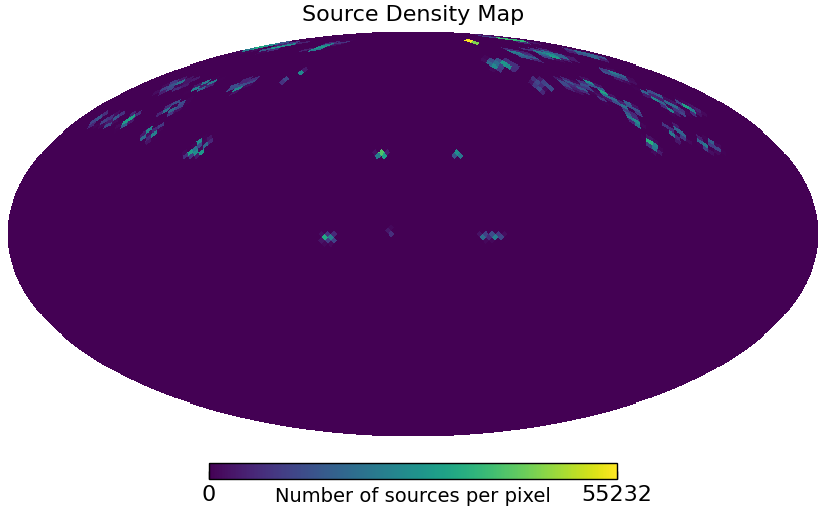

In [11]:
nside = 32
npix = hp.nside2npix(nside)
theta = np.radians(90.0 - data['DEC'])
phi = np.radians(data['RA'] % 360.0)
pix_indices = hp.ang2pix(nside, theta, phi)
hpx_map = np.bincount(pix_indices, minlength=npix)
hp.mollview(hpx_map, title='Source Density Map', unit='Number of sources per pixel')
plt.show()

In [12]:
valid_south_g = np.isfinite(flux_r[0])

In [13]:
bins = np.linspace(14,32,50)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
dm  = np.diff(bin_centers)[0]

In [14]:
bin_centers

array([14.18367347, 14.55102041, 14.91836735, 15.28571429, 15.65306122,
       16.02040816, 16.3877551 , 16.75510204, 17.12244898, 17.48979592,
       17.85714286, 18.2244898 , 18.59183673, 18.95918367, 19.32653061,
       19.69387755, 20.06122449, 20.42857143, 20.79591837, 21.16326531,
       21.53061224, 21.89795918, 22.26530612, 22.63265306, 23.        ,
       23.36734694, 23.73469388, 24.10204082, 24.46938776, 24.83673469,
       25.20408163, 25.57142857, 25.93877551, 26.30612245, 26.67346939,
       27.04081633, 27.40816327, 27.7755102 , 28.14285714, 28.51020408,
       28.87755102, 29.24489796, 29.6122449 , 29.97959184, 30.34693878,
       30.71428571, 31.08163265, 31.44897959, 31.81632653])

In [15]:
counts = np.digitize(flux_r[0][valid_south_g], bins=bins) -1

In [16]:
bins

array([14.        , 14.36734694, 14.73469388, 15.10204082, 15.46938776,
       15.83673469, 16.20408163, 16.57142857, 16.93877551, 17.30612245,
       17.67346939, 18.04081633, 18.40816327, 18.7755102 , 19.14285714,
       19.51020408, 19.87755102, 20.24489796, 20.6122449 , 20.97959184,
       21.34693878, 21.71428571, 22.08163265, 22.44897959, 22.81632653,
       23.18367347, 23.55102041, 23.91836735, 24.28571429, 24.65306122,
       25.02040816, 25.3877551 , 25.75510204, 26.12244898, 26.48979592,
       26.85714286, 27.2244898 , 27.59183673, 27.95918367, 28.32653061,
       28.69387755, 29.06122449, 29.42857143, 29.79591837, 30.16326531,
       30.53061224, 30.89795918, 31.26530612, 31.63265306, 32.        ])

In [17]:
np.unique(counts)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [18]:
N,_ = np.histogram(MAG_south['R'], bins=bins)
dN_dOmega_dm = N / south_area /bin_centers

NameError: name 'MAG_south' is not defined

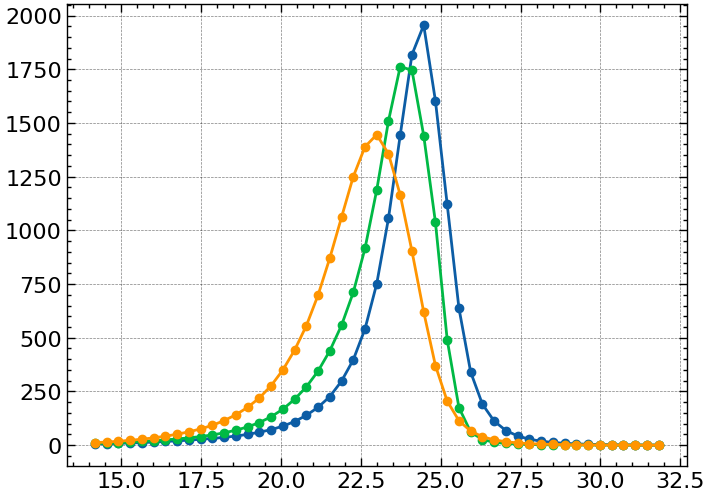

In [ ]:
plt.figure()

for band in ['G','R','Z']:
    N,_ = np.histogram(MAG_south[band], bins=bins)
    dN_dOmega_dm = N / 8000 / dm
    plt.plot(bin_centers, dN_dOmega_dm, marker="o")
    #plt.yscale("log")

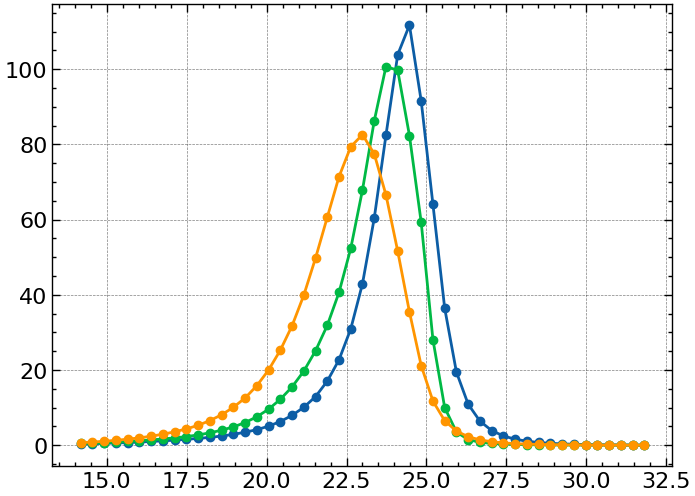

In [ ]:
plt.figure()

for band in ['G','R','Z']:
    N,_ = np.histogram(MAG_south[band], bins=bins)
    dN_dOmega_dm = N / south_area / dm
    plt.plot(bin_centers, dN_dOmega_dm, marker="o")
    #plt.yscale("log")

In [24]:
bands = ['G','R','Z']
MAG_south = {}
for band in bands:
    flux = flux_mag(data[f'FLUX_{band}'], data[f'MW_TRANSMISSION_{band}'])
    mask = np.isfinite(flux[0])
    MAG_south[band] = flux[0][mask]



/user/animesh.sah/DESI_PECVEL/notebooks/flux_to_mag_desi.py:17: RuntimeWarning: divide by zero encountered in log10
  mag = -2.5 * np.log10(flux_corr) + 22.5
/user/animesh.sah/DESI_PECVEL/notebooks/flux_to_mag_desi.py:17: RuntimeWarning: invalid value encountered in log10
  mag = -2.5 * np.log10(flux_corr) + 22.5


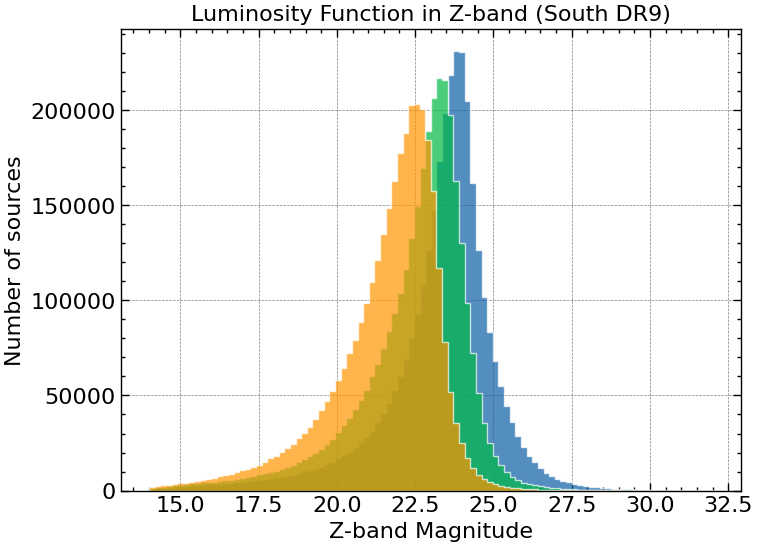

In [ ]:
plt.figure(figsize=(8,6))

for band in bands:
    plt.hist(MAG_south[band], bins=100, range=(14,32), histtype='stepfilled',edgecolor='w', alpha=0.7)
    #plt.yscale('log')
    plt.xlabel(f'{band}-band Magnitude')
    plt.ylabel('Number of sources')
    plt.title(f'Luminosity Function in {band}-band (South DR9)')
    #plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

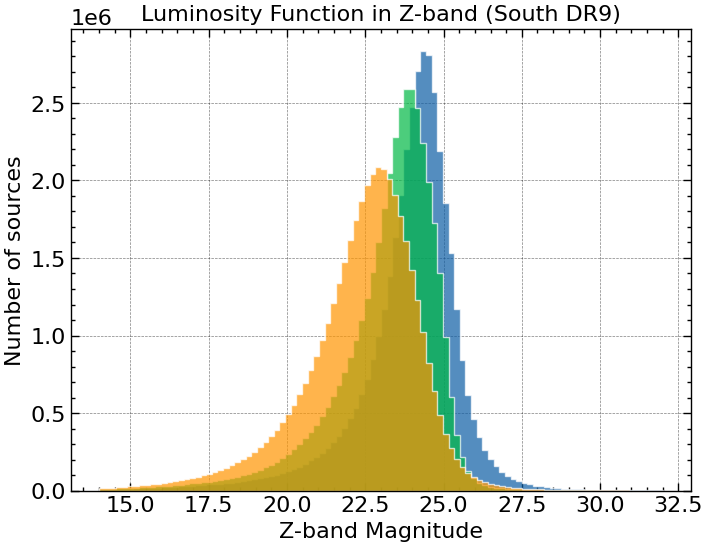

In [ ]:
plt.figure(figsize=(8,6))

for band in bands:
    plt.hist(MAG_south[band], bins=100, range=(14,32), histtype='stepfilled',edgecolor='w', alpha=0.7)
    #plt.yscale('log')
    plt.xlabel(f'{band}-band Magnitude')
    plt.ylabel('Number of sources')
    plt.title(f'Luminosity Function in {band}-band (South DR9)')
    #plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

In [ ]:
np.loadtxt('/user/animesh.sah/DESI_PECVEL/magnitude_bins/south_magnitude_counts_Z.txt')

array([[1.40000000e+01, 5.06819000e+05],
       [1.41818182e+01, 5.68943000e+05],
       [1.43636364e+01, 6.35679000e+05],
       [1.45454545e+01, 7.05180000e+05],
       [1.47272727e+01, 7.81414000e+05],
       [1.49090909e+01, 8.63213000e+05],
       [1.50909091e+01, 9.53654000e+05],
       [1.52727273e+01, 1.05528200e+06],
       [1.54545455e+01, 1.16913200e+06],
       [1.56363636e+01, 1.29405700e+06],
       [1.58181818e+01, 1.43059700e+06],
       [1.60000000e+01, 1.58400400e+06],
       [1.61818182e+01, 1.75290700e+06],
       [1.63636364e+01, 1.94000300e+06],
       [1.65454545e+01, 2.14076100e+06],
       [1.67272727e+01, 2.36743900e+06],
       [1.69090909e+01, 2.61614200e+06],
       [1.70909091e+01, 2.88705700e+06],
       [1.72727273e+01, 3.18909200e+06],
       [1.74545455e+01, 3.52964800e+06],
       [1.76363636e+01, 3.90046400e+06],
       [1.78181818e+01, 4.32651300e+06],
       [1.80000000e+01, 4.81675200e+06],
       [1.81818182e+01, 5.37501700e+06],
       [1.836363

In [16]:
magnitude_counts ={}
for region in ['north','south']:
    magnitude_counts[region] = {}
    for band in bands:
        magnitude_counts[region][band] = np.loadtxt(f'/user/animesh.sah/DESI_PECVEL/magnitude_bins/{region}_magnitude_counts_{band}.txt')[:,1]
bins  = np.loadtxt(f'/user/animesh.sah/DESI_PECVEL/magnitude_bins/{region}_magnitude_counts_{band}.txt')[:,0]


NameError: name 'bands' is not defined

In [13]:
north_table = Table(fitsio.FITS(f'../../FP_CUTS/table_north_unique.fits')[1].read())


south_table = Table(fitsio.FITS(f'../../FP_CUTS/table_south_unique.fits')[1].read())
south_degraded =Table(fitsio.FITS(f'/user/animesh.sah/FP_CUTS/table_south_degraded_unique.fits')[1].read())
south_degraded_constant_error =Table(fitsio.FITS(f'/user/animesh.sah/FP_CUTS/south_cuts_degraded_constant_error.fits')[1].read())

In [15]:
south_degraded = south_degraded[south_degraded['RA']>-30]
south_degraded_constant_error = south_degraded_constant_error[south_degraded_constant_error['RA']>-30]

In [30]:
len(south_degraded), len(south_degraded_constant_error)

(337012, 207566)

In [18]:
from astropy.table import join

# Find common elements between south_table and south_degraded based on BRICKID and OBJID

south_table_common = join(south_table, south_degraded, keys=['BRICKID', 'OBJID'], table_names=['', '_degraded'])
south_degraded_common = south_table_common

# Alternative approach if you want separate tables with matching rows:
# Create a unique identifier for matching
south_table_id = [f"{bid}_{oid}" for bid, oid in zip(south_table['BRICKID'], south_table['OBJID'])]
south_degraded_id = [f"{bid}_{oid}" for bid, oid in zip(south_degraded['BRICKID'], south_degraded['OBJID'])]

# Find common IDs
common_ids = set(south_table_id) & set(south_degraded_id)

# Create masks for common elements
mask_south_table = np.isin(south_table_id, list(common_ids))
mask_south_degraded = np.isin(south_degraded_id, list(common_ids))

# Extract common rows
south_table_common = south_table[mask_south_table]
south_degraded_common = south_degraded[mask_south_degraded]

print(f"Number of common elements: {len(south_table_common)}")

Number of common elements: 335888


(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.50730663e-02, 4.01948435e-02, 6.53166207e-02, 1.45706308e-01,
        2.76339549e-01, 1.20584530e-01, 1.55755019e-01, 1.40681952e-01,
        1.70828085e-01, 2.96436971e-01, 4.72289411e-01, 6.33068785e-01,
        1.17067482e+00, 1.42189259e+00, 1.87910893e+00, 2.28105737e+00,
        2.71315194e+00, 3.06988117e+00, 3.67782818e+00, 3.74314480e+00,
        3.64265769e+00, 3.97928951e+00, 3.99436257e+00, 3.59743849e+00,
        4.07977661e+00, 3.87377804e+00, 4.41640843e+00, 4.73294282e+00,
        5.00425801e+00, 5.25547579e+00, 4.74801589e+00, 5.21025659e+00,
        5.94883684e+00, 5.76293569e+00, 6.18498154e+00, 6.61707611e+00,
        7.03409761e+00, 7.52146009e+00, 7.64204462e+00, 7.73750737e+00,
        8.62179393e+00, 9.06393721e+00, 1.02195390e+01, 1.02697825e+01,
        1.07521206e+01, 1.09480705e+01, 1.10937768e+01, 1.16966995e+01,
        1.22343055e+01, 1.17218212e+01, 1.15610419e+01, 1.231971

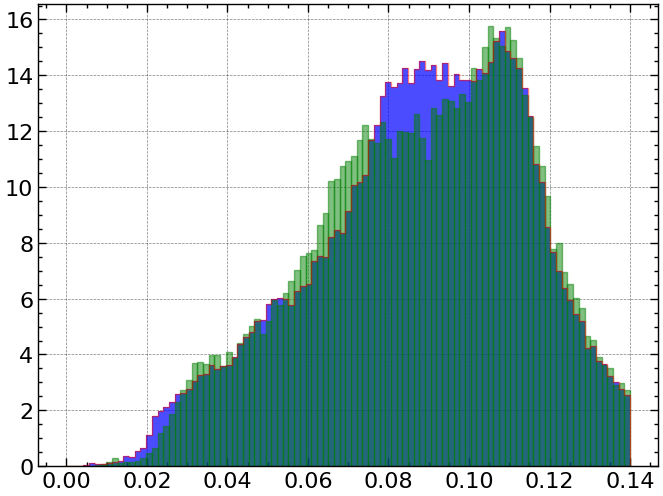

In [22]:
bins_z =  np.linspace(0,0.14,100)
plt.hist(south_table_common['Z_PHOT_MEDIAN'], bins=bins_z, color='b', alpha=0.7,density=True)
plt.hist(south_degraded_common['Z_PHOT_MEDIAN'], bins=bins_z, color='r', alpha=0.5,histtype='step',density=True)
#plt.hist(south_degraded_constant_error['Z_PHOT_MEDIAN'], bins=bins_z, color='k', alpha=0.5,histtype='step',density=True)
plt.hist(north_table['Z_PHOT_MEDIAN'], bins=bins_z, color='g', alpha=0.5,density=True,edgecolor='g')  


In [ ]:
np.mean(south_degraded_common['MAG_R']- south_table_common['MAG_R']), np.mean(south_degraded_common['MAG_G']- south_table_common['MAG_G']), np.mean(south_degraded_common['MAG_Z']- south_table_common['MAG_Z'])

(-1.8836015e-05, 4.5538654e-06, 1.1607699e-05)

(array([2.0000e+00, 1.0000e+00, 1.0000e+00, 6.0000e+00, 8.0000e+00,
        1.8000e+01, 1.5000e+01, 2.7000e+01, 4.8000e+01, 5.8000e+01,
        9.4000e+01, 1.6300e+02, 3.1100e+02, 4.9000e+02, 7.3500e+02,
        1.1690e+03, 1.8090e+03, 2.7080e+03, 4.3650e+03, 6.4560e+03,
        9.8760e+03, 1.5111e+04, 2.1991e+04, 2.9361e+04, 3.5209e+04,
        3.9107e+04, 4.2507e+04, 4.3983e+04, 4.2163e+04, 3.8096e+04]),
 array([ 8.47746372,  8.79488182,  9.11229897,  9.42971706,  9.74713421,
        10.06455231, 10.38196945, 10.69938755, 11.01680565, 11.33422279,
        11.65164089, 11.96905804, 12.28647614, 12.60389328, 12.92131138,
        13.23872948, 13.55614662, 13.87356472, 14.19098186, 14.50839996,
        14.82581711, 15.14323521, 15.46065235, 15.77807045, 16.09548759,
        16.41290665, 16.73032379, 17.04774094, 17.36515808, 17.68257713,
        17.99999428]),
 <BarContainer object of 30 artists>)

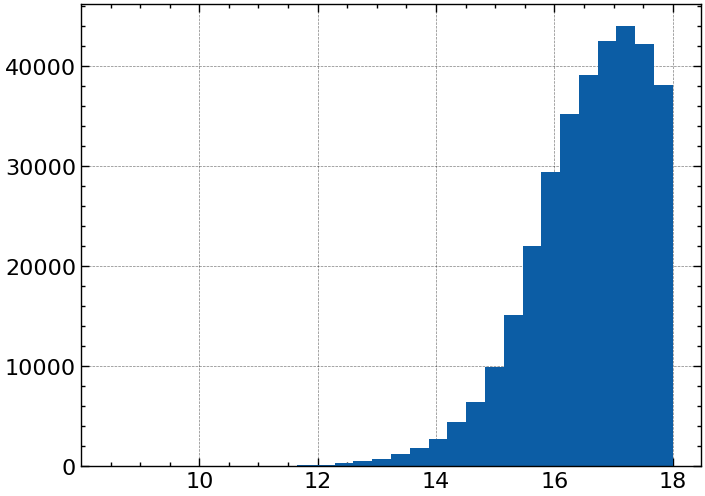

In [29]:
plt.hist(south_degraded_common['MAG_R'],bins = 30)

In [ ]:
np.median(south_degraded_common['MAG_R']- south_table_common['MAG_R']), np.median(south_degraded_common['MAG_G']- south_table_common['MAG_G']), np.median(south_degraded_common['MAG_Z']- south_table_common['MAG_Z'])

(-7.6293945e-06, 0.0, 5.722046e-06)

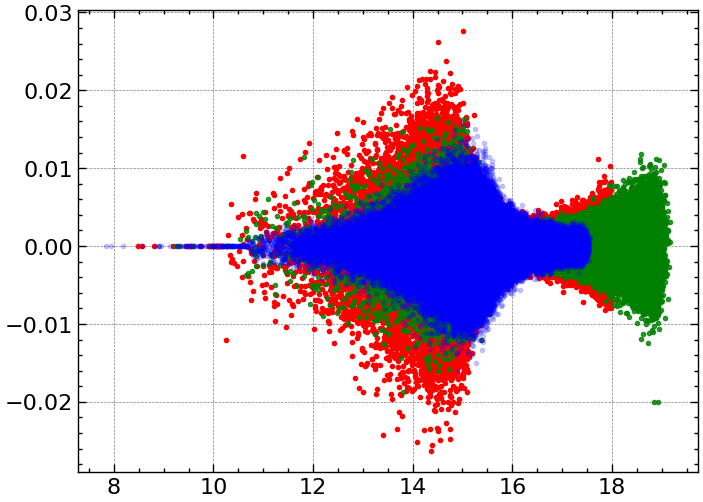

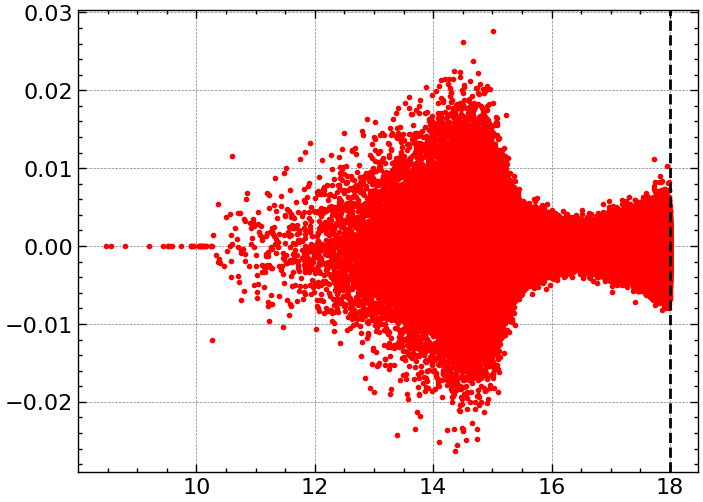

In [ ]:
plt.plot(south_table_common['MAG_R'],south_degraded_common['MAG_R']- south_table_common['MAG_R'],'r.')
plt.plot(south_table_common['MAG_G'],south_degraded_common['MAG_G']- south_table_common['MAG_G'],'g.',alpha = 0.8)
plt.plot(south_table_common['MAG_Z'],south_degraded_common['MAG_Z']- south_table_common['MAG_Z'],'b.',alpha=0.2 )

plt.show()
plt.plot(south_table_common['MAG_R'],south_degraded_common['MAG_R']- south_table_common['MAG_R'],'r.')
plt.axvline(18,color='k',ls='--')

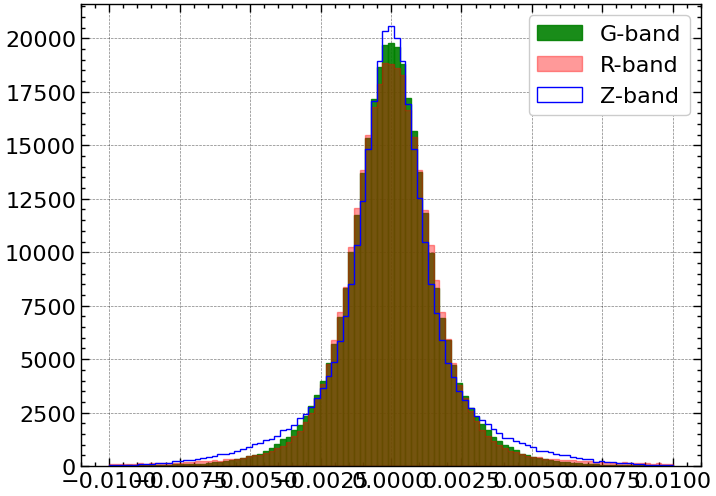

In [ ]:
mag_g_difference = south_table_common['MAG_G']  - south_degraded_common['MAG_G']  
mag_r_difference = south_table_common['MAG_R']  - south_degraded_common['MAG_R']
mag_z_difference = south_table_common['MAG_Z']  - south_degraded_common['MAG_Z']
bins = np.linspace(-0.01,0.01,100)
plt.hist(mag_g_difference, bins=bins,edgecolor='g', alpha=0.9,color = 'g',label='G-band') 
plt.hist(mag_r_difference, bins=bins, histtype='stepfilled',edgecolor='r', alpha=0.4,color = 'r',label='R-band')
plt.hist(mag_z_difference, bins=bins , histtype='step', alpha=1,color = 'b',label='Z-band')
plt.legend()

In [ ]:
# for band in bands:
#     mag_s = flux_mag(south_table[f'FLUX_{band}'], south_table[f'MW_TRANSMISSION_{band}'])[0]
#     mag_n = flux_mag(north_table[f'FLUX_{band}'], north_table[f'MW_TRANSMISSION_{band}'])[0]
#     north_table[f'MAG_{band}'] = mag_n
#     south_table[f'MAG_{band}'] = mag_s

In [ ]:
#fp_north


(array([2.0000e+00, 1.0000e+00, 1.0000e+00, 6.0000e+00, 8.0000e+00,
        1.8000e+01, 1.6000e+01, 2.7000e+01, 4.9000e+01, 5.9000e+01,
        9.6000e+01, 1.7100e+02, 3.1600e+02, 4.9900e+02, 7.4300e+02,
        1.1940e+03, 1.8490e+03, 2.7500e+03, 4.4170e+03, 6.5220e+03,
        9.9450e+03, 1.5167e+04, 2.2066e+04, 2.9438e+04, 3.5287e+04,
        3.9183e+04, 4.2580e+04, 4.4078e+04, 4.2238e+04, 3.8286e+04]),
 array([ 8.47746372,  8.79488182,  9.11229897,  9.42971706,  9.74713421,
        10.06455231, 10.38196945, 10.69938755, 11.01680565, 11.33422279,
        11.65164089, 11.96905804, 12.28647614, 12.60389328, 12.92131138,
        13.23872948, 13.55614662, 13.87356472, 14.19098186, 14.50839996,
        14.82581711, 15.14323521, 15.46065235, 15.77807045, 16.09548759,
        16.41290665, 16.73032379, 17.04774094, 17.36515808, 17.68257713,
        17.99999428]),
 <BarContainer object of 30 artists>)

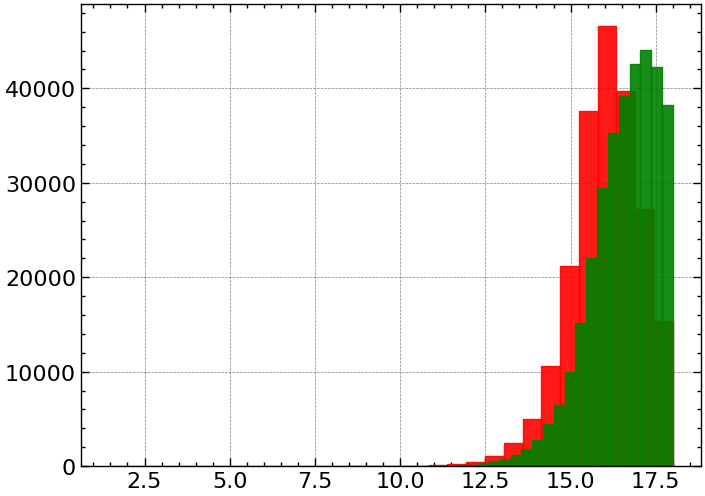

In [29]:
plt.hist(south_degraded_constant_error[f'MAG_R'], bins=30, edgecolor='r', alpha=0.9,color = 'r',label='R-band')
plt.hist(south_degraded[f'MAG_R'], bins=30, edgecolor='g', alpha=0.9,color = 'g',label='G-band')

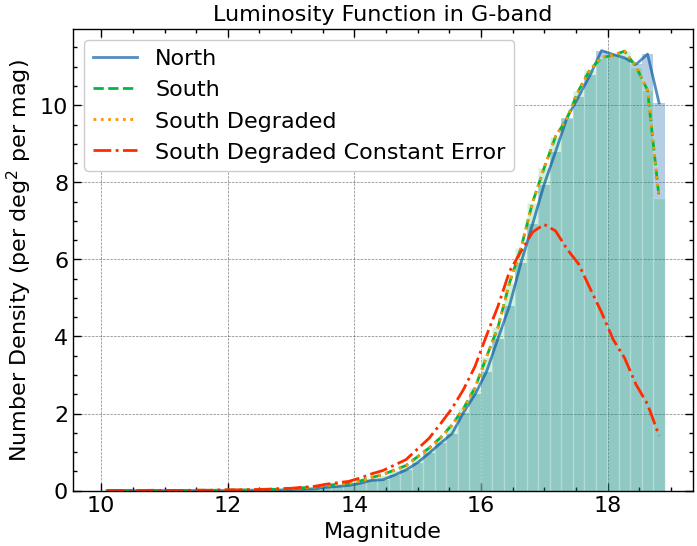

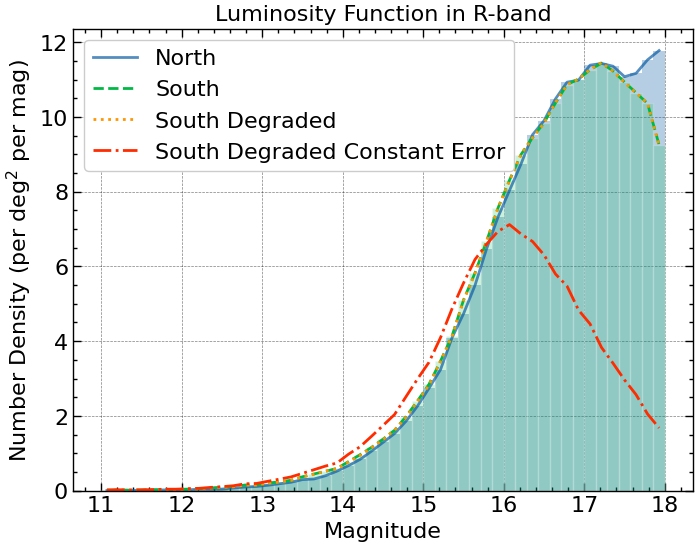

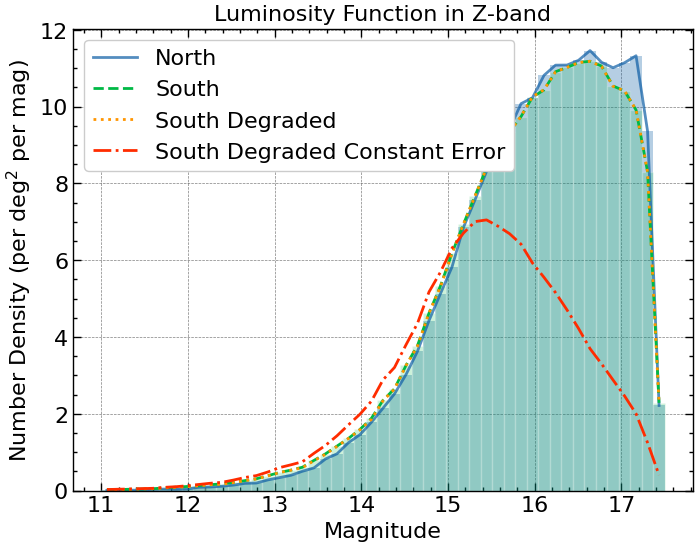

In [26]:
for band in bands:
    if band =='R':
        bins_fp = np.linspace(11,18,50)
    elif band =='G':
        bins_fp = np.linspace(10,18.9,50)
    else:
        bins_fp = np.linspace(11,17.5,50)

    counts_fp_north,_ = np.histogram(north_table[f'MAG_{band}'], bins=bins_fp)
    counts_fp_south,_ = np.histogram(south_table[f'MAG_{band}'], bins=bins_fp)
    counts_fp_south_degraded,_ = np.histogram(south_degraded[f'MAG_{band}'], bins=bins_fp)
    counts_fp_south_degraded_constant_error,_ = np.histogram(south_degraded_constant_error[f'MAG_{band}'], bins=bins_fp)
    bins_centers_fp = 0.5 * (bins_fp[1:] + bins_fp[:-1])
    area_north=5167.3 
    area_south=12213.4

    plt.bar(bins_centers_fp,counts_fp_north/area_north/np.diff(bins_fp)[0], width=np.diff(bins_fp)[0], alpha=0.3)
    plt.bar(bins_centers_fp,counts_fp_south/area_south/np.diff(bins_fp)[0], width=np.diff(bins_fp)[0], alpha=0.2,edgecolor='w')

    plt.plot(bins_centers_fp,counts_fp_north/area_north/np.diff(bins_fp)[0], '-', alpha=0.7, label='North')
    plt.plot(bins_centers_fp,counts_fp_south/area_south/np.diff(bins_fp)[0], '--',label='South')
    plt.plot(bins_centers_fp,counts_fp_south_degraded/area_south/np.diff(bins_fp)[0], ':',label='South Degraded')
    plt.plot(bins_centers_fp,counts_fp_south_degraded_constant_error/area_south/np.diff(bins_fp)[0], '-.',label='South Degraded Constant Error')
    #plt.yscale('log')
    plt.xlabel('Magnitude')
    plt.ylabel('Number Density (per deg$^2$ per mag)')
    plt.title(f'Luminosity Function in {band}-band')   
    #plt.xscale('log')
    #plt.bar(bins_centers_fp,counts_fp_south_degraded/area_south/np.diff(bins_fp)[0], width=np.diff(bins_fp)[0], alpha=0.7, label='South Degraded')
    plt.legend()
    plt.show()

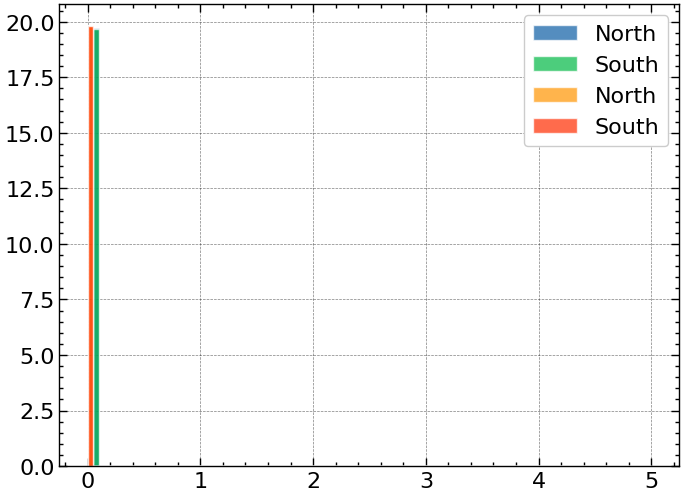

In [ ]:
bins = np.linspace(0,5,100)
for region in ['north','south']:
    area_north=5167.3 
    area_south=12213.4
    plt.hist(north_table['MAG_R']/(area_north if region=='north' else area_south)/np.diff(bins)[0], bins=bins, histtype='stepfilled',edgecolor='w', alpha=0.7, label='North',density=True)
    plt.hist(south_table['MAG_R']/(area_north if region=='north' else area_south)/np.diff(bins)[0], bins=bins, histtype='stepfilled',edgecolor='w', alpha=0.7, label='South',density=True)
    plt.legend()
plt.show()

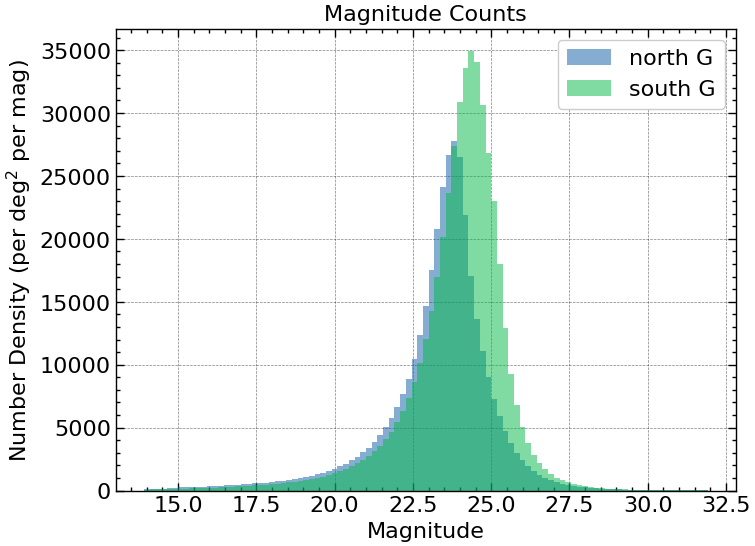

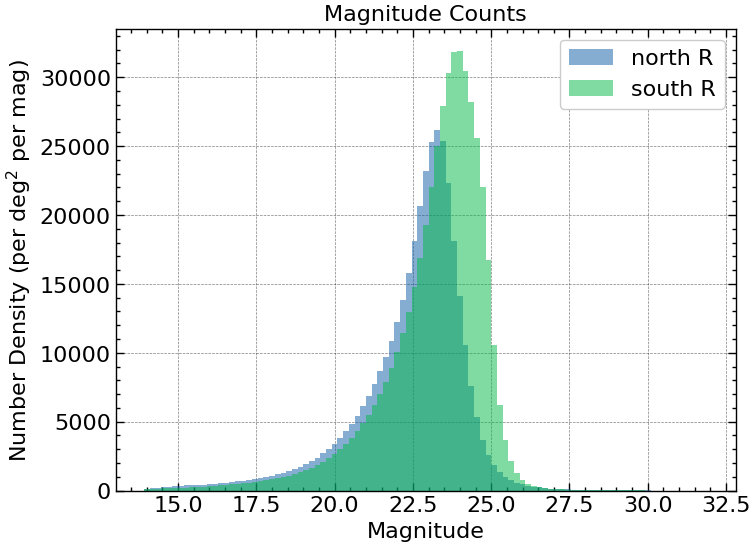

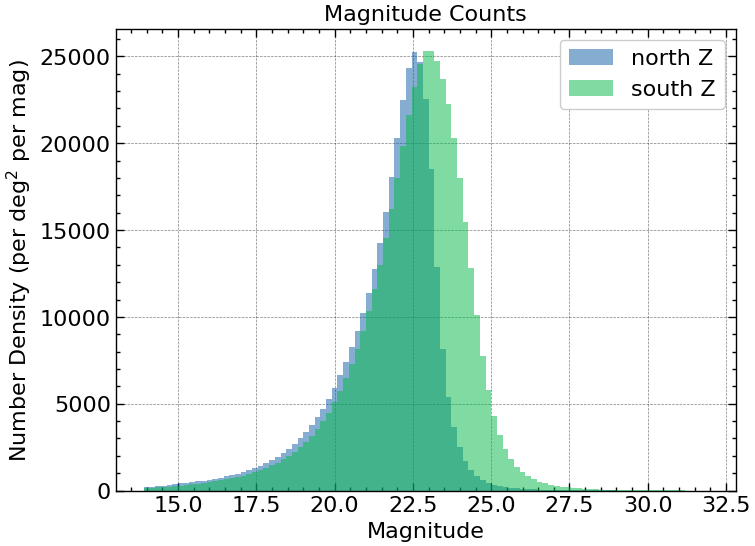

In [ ]:
area_north=5167.3
area_south=12213.4*1.5
plt.figure(figsize=(8,6))
for band in bands:
    for region in ['north','south']:
        plt.bar(bins, magnitude_counts[region][band]/(area_north if region=='north' else area_south)/np.diff(bins)[0], width=np.diff(bins)[0], alpha=0.5, label=f'{region} {band}')
        plt.xlabel('Magnitude')
        plt.ylabel('Number Density (per deg$^2$ per mag)')
        #plt.yscale('log')
        plt.title('Magnitude Counts')
        plt.legend()
    plt.show()